# Random Noise vs Adversarial Attack

This notebook visualizes the fundamental difference between random noise and adversarial perturbations in the latent space of a CNN. 

We extract the high-dimensional feature vectors (embeddings) from the penultimate layer of the models. By projecting these features into a 2D space using Principal Component Analysis (PCA), we can observe how adding random noise keeps the image within a local cluster, whereas an FGSM attack pushes the feature vector in a highly specific, vulnerable direction, completely escaping the natural neighborhood of the original image.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Import models
from tensorflow.keras.applications import EfficientNetB0, InceptionV3, MobileNetV2

# Import specific preprocessing and decoding functions
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_eff
from tensorflow.keras.applications.inception_v3 import preprocess_input as preprocess_inc
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as preprocess_mob

In [2]:
# Dictionary with model configurations
models_dict = {
    'MobileNetV2': {
        'model': MobileNetV2(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_mob,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    },
    'EfficientNetB0': {
        'model': EfficientNetB0(weights='imagenet'),
        'target_size': (224, 224),
        'preprocess_fn': preprocess_eff,
        'clip_min': 0.0,
        'clip_max': 255.0,
        'eps_scale': 127.5
    },
    'InceptionV3': {
        'model': InceptionV3(weights='imagenet'),
        'target_size': (299, 299),
        'preprocess_fn': preprocess_inc,
        'clip_min': -1.0,
        'clip_max': 1.0,
        'eps_scale': 1.0
    }
}

# Freeze weights as we only need to perform inference and compute gradients w.r.t inputs
for config in models_dict.values():
    config['model'].trainable = False

# Dictionary for target images
images_dict = {
    'Dog': '../images/dog.png',
    'Lion': '../images/lion.png'
}

In [3]:
def load_and_preprocess_image(img_path, target_size, preprocess_fn):
    img_raw = tf.io.read_file(img_path)
    img = tf.image.decode_image(img_raw, channels=3)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, target_size)
    img = preprocess_fn(img) # Dynamic preprocessing
    img = tf.expand_dims(img, axis=0) # Add batch dimension
    return img

In [4]:
loss_object = tf.keras.losses.CategoricalCrossentropy()

def fgsm_attack(input_image, input_label, epsilon, current_model):
    with tf.GradientTape() as tape:
        tape.watch(input_image)
        prediction = current_model(input_image)
        loss = loss_object(input_label, prediction)
    
    # Get gradients of the loss w.r.t to the input image
    gradient = tape.gradient(loss, input_image)
    
    # Get the sign of the gradients
    signed_grad = tf.sign(gradient)
    
    # Create the adversarial image
    adv_image = input_image + epsilon * signed_grad
    return adv_image

### Feature Extraction and PCA Visualization
For each model and image, we generate 200 variations with uniform random noise and 1 adversarial example using FGSM. Both the random noise and the FGSM attack are bounded by the exact same $\varepsilon$ magnitude.


LATENT SPACE ANALYSIS: MobileNetV2

--- Processing Image: Dog ---


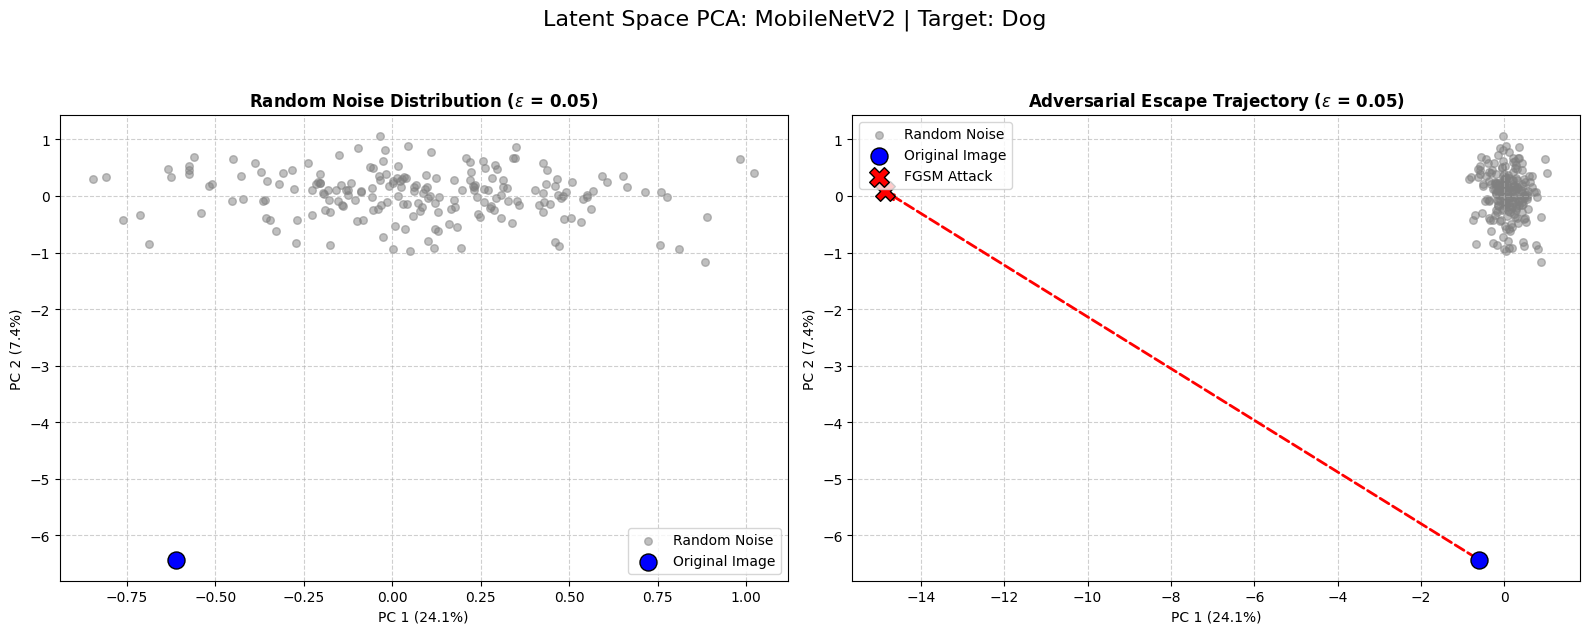

--- Processing Image: Lion ---


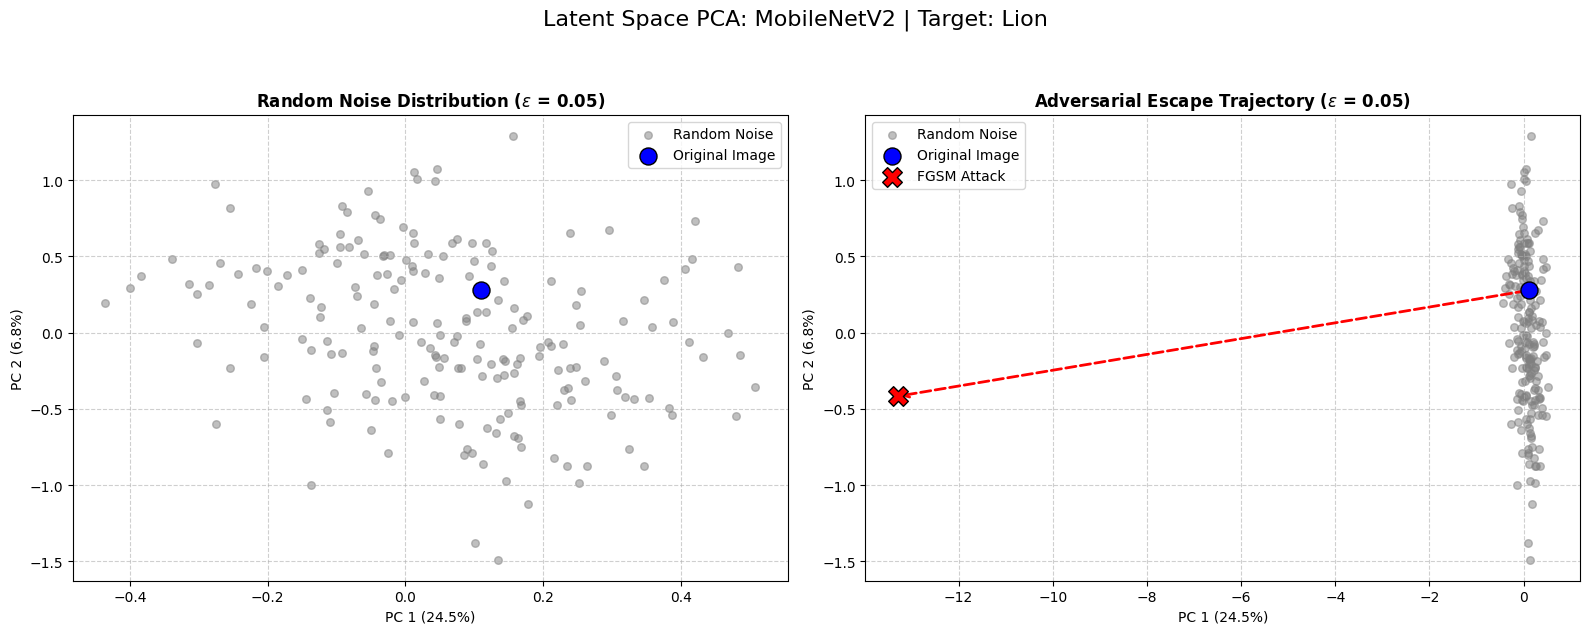


LATENT SPACE ANALYSIS: EfficientNetB0

--- Processing Image: Dog ---


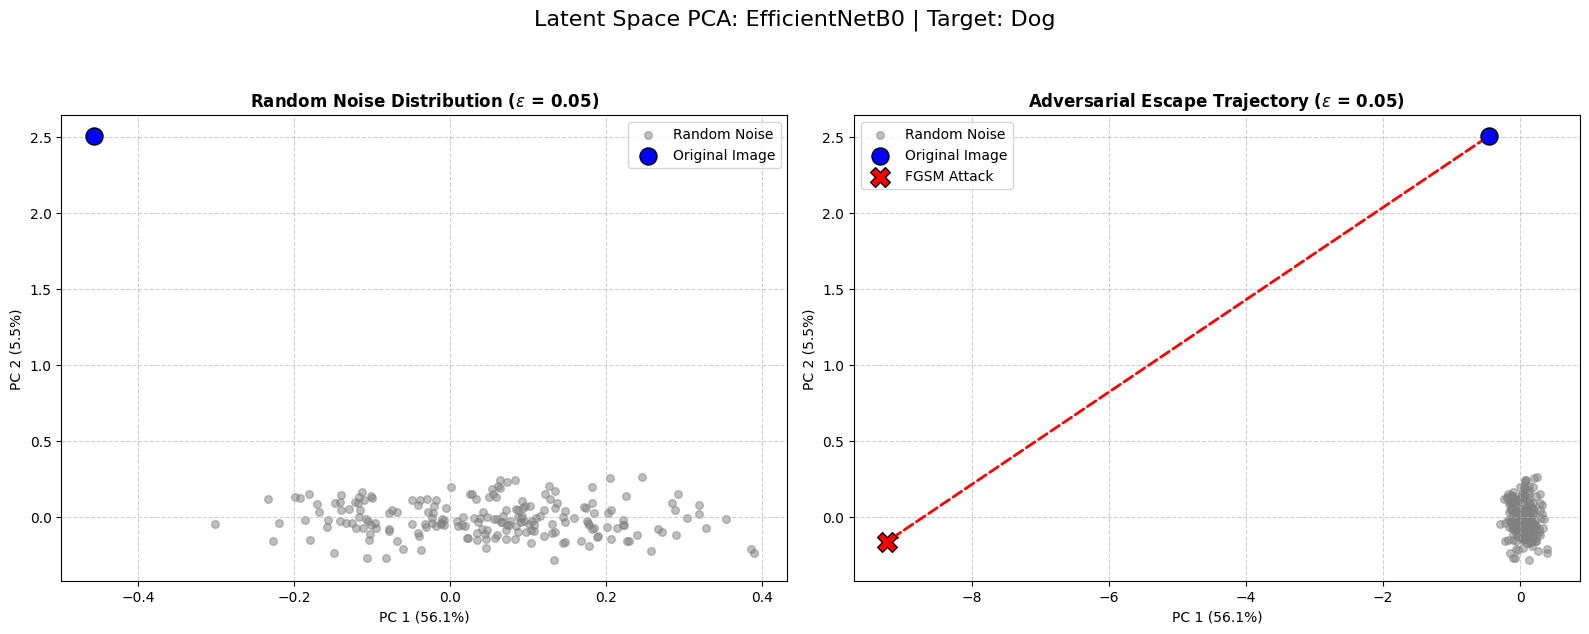

--- Processing Image: Lion ---


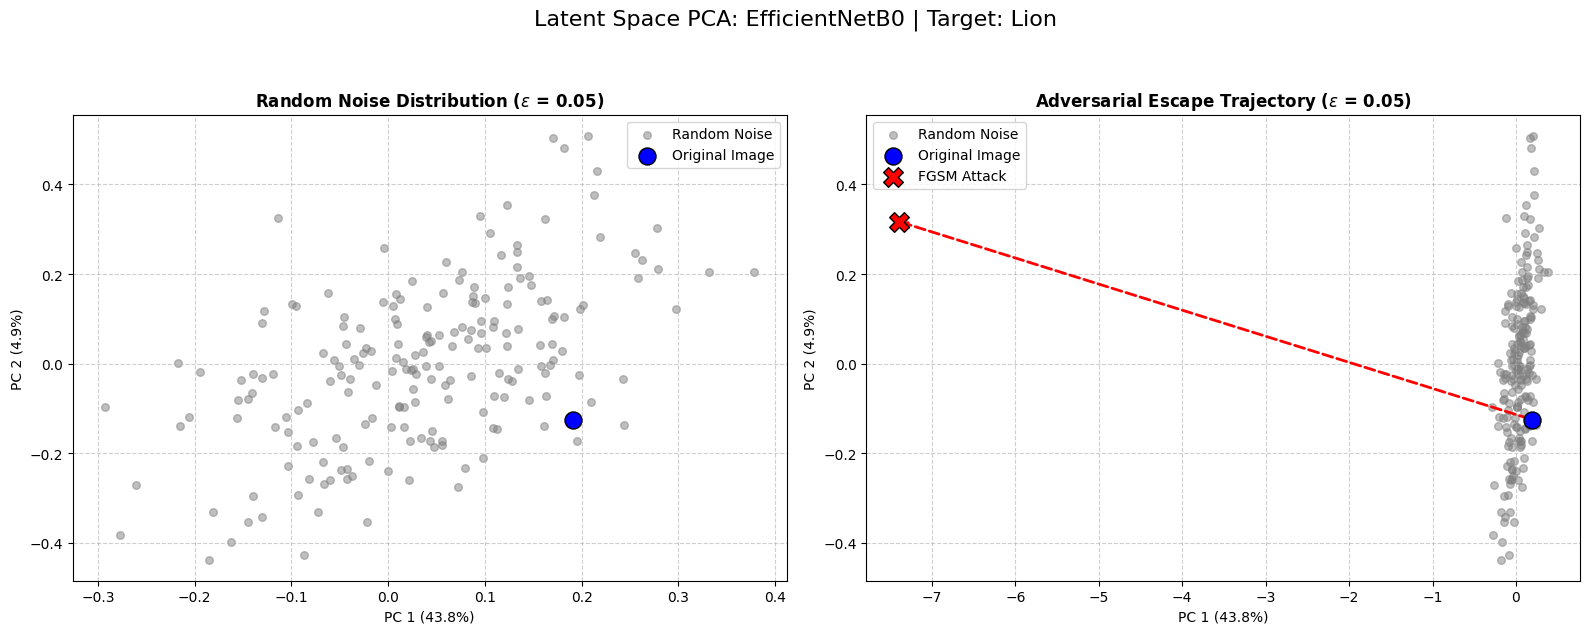


LATENT SPACE ANALYSIS: InceptionV3

--- Processing Image: Dog ---


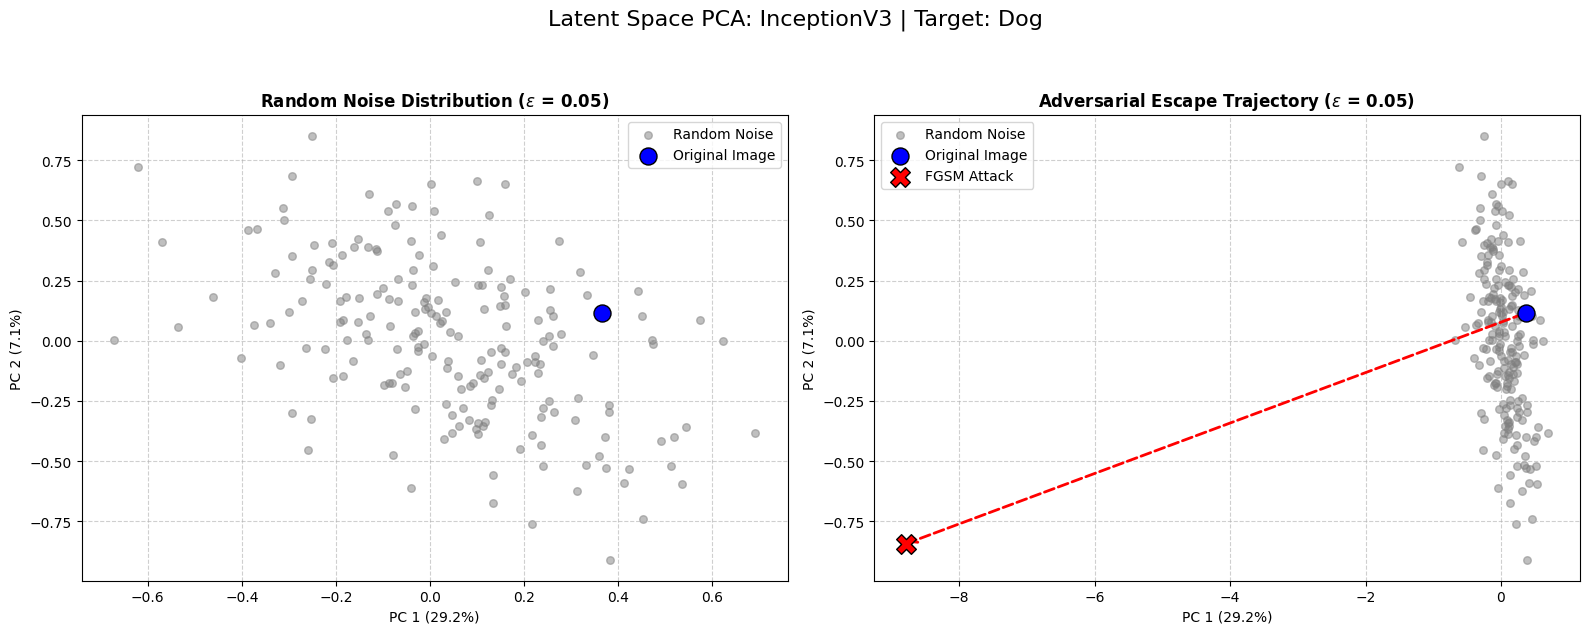

--- Processing Image: Lion ---


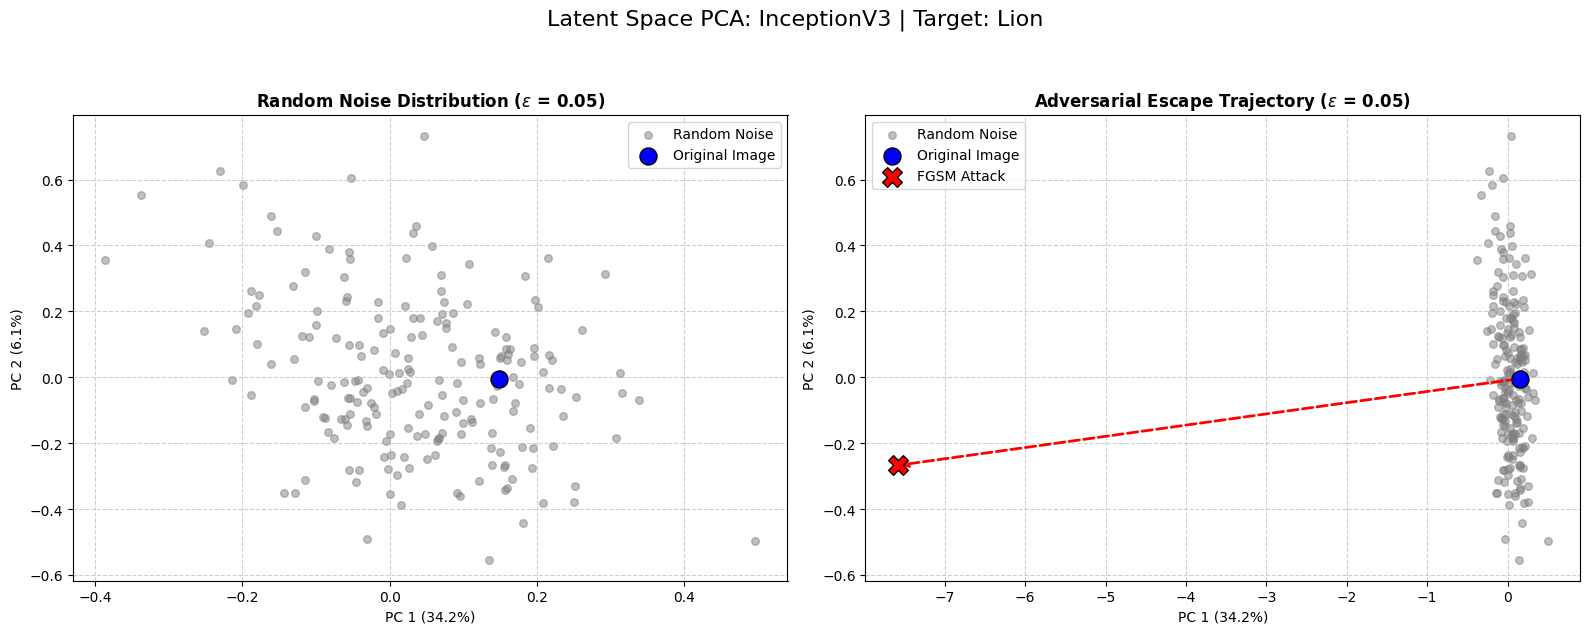

In [5]:
base_epsilon = 0.05 # Base perturbation magnitude
num_random_samples = 200 # Number of random noise images to generate

for model_name, m_config in models_dict.items():
    # Print a clear header when switching models
    print(f"\n{'='*80}")
    print(f"LATENT SPACE ANALYSIS: {model_name}")
    print(f"{'='*80}\n")
    
    current_model = m_config['model']
    target_size = m_config['target_size']
    preprocess_fn = m_config['preprocess_fn']
    clip_min = m_config['clip_min']
    clip_max = m_config['clip_max']
    
    # Scale epsilon to match the model's expected input range
    epsilon = base_epsilon * m_config['eps_scale']
    
    # Create a feature extractor (outputs the embedding vector before the final classification layer)
    feature_extractor = tf.keras.Model(inputs=current_model.input, outputs=current_model.layers[-1].input)
    
    for img_name, img_path in images_dict.items():
        print(f"--- Processing Image: {img_name} ---")
        
        # Load Original Image
        input_img = load_and_preprocess_image(img_path, target_size, preprocess_fn)
        
        # Get Original Prediction and Label
        original_probs = current_model.predict(input_img, verbose=0)
        class_idx = tf.argmax(original_probs, axis=-1).numpy()[0]
        input_label = tf.reshape(tf.one_hot(class_idx, original_probs.shape[-1]), (1, -1))
        
        # Extract Original Features
        orig_features = feature_extractor.predict(input_img, verbose=0).flatten()
        
        # Generate Random Noise Images (Vectorized for speed)
        tiled_img = tf.tile(input_img, [num_random_samples, 1, 1, 1]) # Tile the input image to create a batch of size 'num_random_samples'
        # Generate uniform noise in the range [-epsilon, epsilon]
        random_noise = tf.random.uniform(tiled_img.shape, minval=-epsilon, maxval=epsilon, dtype=tf.float32)
        # Apply noise and clip
        noisy_imgs = tf.clip_by_value(tiled_img + random_noise, clip_min, clip_max)
        
        # Extract features for all noisy images at once
        noisy_features = feature_extractor.predict(noisy_imgs, batch_size=32, verbose=0)
        
        # Generate FGSM Attacked Image
        adv_img = fgsm_attack(input_img, input_label, epsilon, current_model)
        adv_img = tf.clip_by_value(adv_img, clip_min, clip_max)
        
        # Extract features for the FGSM image
        adv_features = feature_extractor.predict(adv_img, verbose=0).flatten()
        
        # Prepare Data for PCA
        all_features = np.vstack([orig_features, noisy_features, adv_features])
        
        # Fit PCA and reduce to 2 components
        pca = PCA(n_components=2)
        pca_result = pca.fit_transform(all_features)
        
        # Separate the projected points
        pca_orig = pca_result[0]
        pca_noise = pca_result[1:-1]
        pca_adv = pca_result[-1]
        
        # Plotting
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        
        pc1_label = f'PC 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)'
        pc2_label = f'PC 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)'
        
        # Plot 1: Only Original and Noise
        ax1.scatter(pca_noise[:, 0], pca_noise[:, 1], c='gray', alpha=0.5, label='Random Noise', s=30)
        ax1.scatter(pca_orig[0], pca_orig[1], c='blue', marker='o', s=150, edgecolors='black', label='Original Image', zorder=5)
        ax1.set_title(f'Random Noise Distribution ($\epsilon$ = {base_epsilon})', fontweight='bold')
        ax1.set_xlabel(pc1_label)
        ax1.set_ylabel(pc2_label)
        ax1.legend(loc='best')
        ax1.grid(True, linestyle='--', alpha=0.6)
        
        # Plot 2: Original, Noise, and FGSM Attack
        ax2.scatter(pca_noise[:, 0], pca_noise[:, 1], c='gray', alpha=0.5, label='Random Noise', s=30)
        ax2.scatter(pca_orig[0], pca_orig[1], c='blue', marker='o', s=150, edgecolors='black', label='Original Image', zorder=5)
        ax2.scatter(pca_adv[0], pca_adv[1], c='red', marker='X', s=200, edgecolors='black', label='FGSM Attack', zorder=5)
        
        # Arrow highlighting the escape trajectory
        ax2.annotate('', xy=(pca_adv[0], pca_adv[1]), xytext=(pca_orig[0], pca_orig[1]),
                     arrowprops=dict(arrowstyle='->', color='red', lw=2, ls='--'))
        
        ax2.set_title(f'Adversarial Escape Trajectory ($\epsilon$ = {base_epsilon})', fontweight='bold')
        ax2.set_xlabel(pc1_label)
        ax2.set_ylabel(pc2_label)
        ax2.legend(loc='best')
        ax2.grid(True, linestyle='--', alpha=0.6)
        
        # Title
        plt.suptitle(f'Latent Space PCA: {model_name} | Target: {img_name}', fontsize=16, y=1.05)
        
        plt.tight_layout()
        plt.show()